## 1. Getting the data

In [56]:
from datasets import load_dataset

minds = load_dataset("PolyAI/minds14", name="en-AU", split="train")
minds

Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
    num_rows: 654
})

In [57]:
import datasets

minds = minds.cast_column("audio", datasets.Audio(decode=False))

In [58]:
example = minds[0]
example

{'path': 'en-AU~PAY_BILL/response_4.wav',
 'audio': {'bytes': b'RIFF\x02\xf4\x00\x00WAVEfmt \x12\x00\x00\x00\x07\x00\x01\x00@\x1f\x00\x00@\x1f\x00\x00\x01\x00\x08\x00\x00\x00fact\x04\x00\x00\x00\xcf\xf3\x00\x00data\xcf\xf3\x00\x00\xff\xfe~\xff\xff\xff\xfe\xff\xff\xff\xff\xff\xff\xff\xff\xfe~\xff~\xff\xff\xff\xff\xff\xff~\xff\xff\xfe\xff\xff\xff\xfe\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff~\xff\xff\xff\xff\xff~~~\xff\xff\xfe~\xff\xff\xff\xff\xff\xff\xff\xfe\xff\xfe\xfe~\xff\xff\xff\xfe\xff\xff\xfe\xff~\xff\xff\xff~\xff\xff\xff\xfe\xff\xff~\xff\xff\xfe\xff\xfe\xff\xfe\xff\xff~~\xff\xff\xff\xff\xff\xfe~\xff\xff\xff~\xff\xff\xff\xff\xff\xff\xff\xff\xff\xfe\xfe\xff\xff\xff\xfe~}~\xfd\xfc|z~\xfd}yy|\xffzw|\xfd\xfe||\xfc\xf8\xfb~\xf9\xf0\xf1\xf6\xf8\xf1\xea\xeb\xf4\xf6\xee\xe9\xe9\xf1}\xfa\xee\xf3{nlpmc`ba^[[_b^\\^cknnq|\xf8\xee\xe9\xe6\xe3\xe1\xe1\xde\xdb\xda\xdb\xdd\xdd\xdc\xda\xdc\xe0\xe2\xe0\xe2\xe9\xf1\xf0\xed\xf6piloka]_c`]]_ddbekoqrx\xfb\xf6\xf8\xf9\xf4\xee\xef\xf4\xf9\xf6\xf3\x

In [59]:
import librosa
import numpy as np
import io

example = minds[0]

audio_bytes = example["audio"]["bytes"]

signal, sr = librosa.load(io.BytesIO(audio_bytes), sr=16000)

print(signal.shape, sr)

(124830,) 16000


In [60]:
id2label = minds.features["intent_class"].int2str
id2label(example["intent_class"])

'pay_bill'

In [61]:
columns_to_remove = ["lang_id", "english_transcription"]
minds = minds.remove_columns(columns_to_remove)
minds

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class'],
    num_rows: 654
})

In [62]:
import gradio as gr

with gr.Blocks() as demo:
    with gr.Column():
        output = gr.Audio((sr, signal), label=id2label(example["intent_class"]), type="numpy")

demo.launch(debug=True)

c:\Users\mazen\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\processing_utils.py:689: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Keyboard interruption in main thread... closing server.


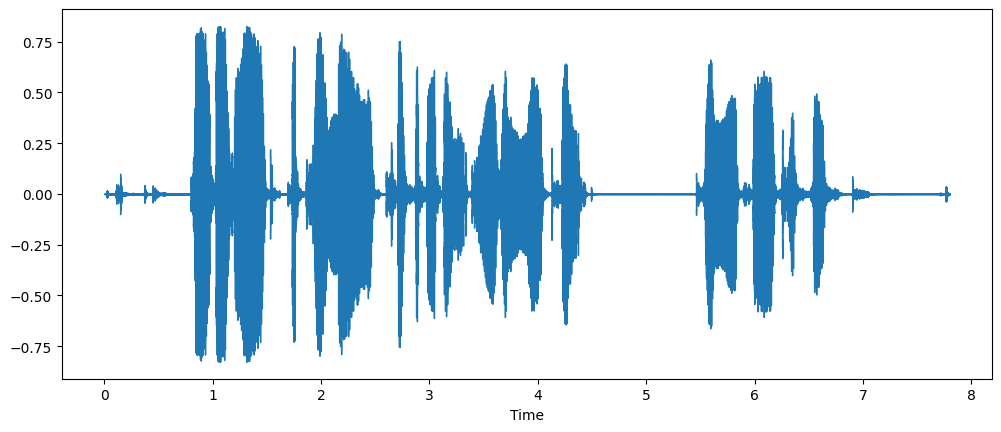

In [63]:
import librosa
import matplotlib.pyplot as plt
import librosa.display

plt.figure().set_figwidth(12)
librosa.display.waveshow(signal, sr=sr)

## 2. Data Preprocessing

In [80]:
from datasets import load_dataset

minds = load_dataset("PolyAI/minds14", name="en-AU", split="train")
minds

Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
    num_rows: 654
})

In [81]:
import datasets

minds = minds.cast_column("audio", datasets.Audio(decode=False))

In [82]:
minds[0]

{'path': 'en-AU~PAY_BILL/response_4.wav',
 'audio': {'bytes': b'RIFF\x02\xf4\x00\x00WAVEfmt \x12\x00\x00\x00\x07\x00\x01\x00@\x1f\x00\x00@\x1f\x00\x00\x01\x00\x08\x00\x00\x00fact\x04\x00\x00\x00\xcf\xf3\x00\x00data\xcf\xf3\x00\x00\xff\xfe~\xff\xff\xff\xfe\xff\xff\xff\xff\xff\xff\xff\xff\xfe~\xff~\xff\xff\xff\xff\xff\xff~\xff\xff\xfe\xff\xff\xff\xfe\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff~\xff\xff\xff\xff\xff~~~\xff\xff\xfe~\xff\xff\xff\xff\xff\xff\xff\xfe\xff\xfe\xfe~\xff\xff\xff\xfe\xff\xff\xfe\xff~\xff\xff\xff~\xff\xff\xff\xfe\xff\xff~\xff\xff\xfe\xff\xfe\xff\xfe\xff\xff~~\xff\xff\xff\xff\xff\xfe~\xff\xff\xff~\xff\xff\xff\xff\xff\xff\xff\xff\xff\xfe\xfe\xff\xff\xff\xfe~}~\xfd\xfc|z~\xfd}yy|\xffzw|\xfd\xfe||\xfc\xf8\xfb~\xf9\xf0\xf1\xf6\xf8\xf1\xea\xeb\xf4\xf6\xee\xe9\xe9\xf1}\xfa\xee\xf3{nlpmc`ba^[[_b^\\^cknnq|\xf8\xee\xe9\xe6\xe3\xe1\xe1\xde\xdb\xda\xdb\xdd\xdd\xdc\xda\xdc\xe0\xe2\xe0\xe2\xe9\xf1\xf0\xed\xf6piloka]_c`]]_ddbekoqrx\xfb\xf6\xf8\xf9\xf4\xee\xef\xf4\xf9\xf6\xf3\x

In [88]:
def process(example):
    signal, sr = librosa.load(io.BytesIO(example["audio"]["bytes"]), sr=16000)
    example["signal"] = signal
    example["sr"] = sr
    return example

minds_copy = minds.map(process)

Map: 100%|██████████| 654/654 [00:04<00:00, 144.93 examples/s]


In [90]:
minds_copy[0].keys()

dict_keys(['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'signal', 'sr'])

In [91]:
# check if the audio  is less than 20 seconds
MAX_DURATION_IN_SECONDS = 20.0

def is_audio_length_in_range(input_length):
    return input_length < MAX_DURATION_IN_SECONDS

In [94]:
# use librosa to get example's duration from the audio file
new_column = [
    librosa.get_duration(y=np.array(x["signal"]), sr=x["sr"]) for x in minds_copy
]
minds_copy = minds_copy.add_column("duration", new_column)

# use 🤗 Datasets' `filter` method to apply the filtering function
minds_copy = minds_copy.filter(is_audio_length_in_range, input_columns=["duration"])

# remove the temporary `duration` column
minds_copy = minds_copy.remove_columns("duration")
minds_copy

Filter: 100%|██████████| 654/654 [00:00<00:00, 14897.00 examples/s]


Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'signal', 'sr'],
    num_rows: 624
})

In [101]:
from transformers import AutoFeatureExtractor

feature_extractor = AutoFeatureExtractor.from_pretrained("openai/whisper-small")

ImportError: cannot import name 'add_model_info_to_auto_map' from 'transformers.utils.generic' (c:\Users\mazen\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\utils\generic.py)